<!-- @@COLAB@@ -->
<a href="https://colab.research.google.com/github/laris-co/ajfon-oracle/blob/main/book/notebooks/ch03_filter_metadata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **เปิดใน Google Colab** — คลิกป้ายด้านบน รันได้ทันทีบนคลาวด์ฟรี ไม่ต้องติดตั้งอะไรในเครื่อง (เซลล์แรกจะ `pip install` ให้เอง)


# 📗 บทที่ 3 — ค้นแบบมีเงื่อนไข: semantic + metadata พร้อมกัน

**คู่กับ:** หนังสือบทที่ 3

คำค้นจริงเป็นลูกผสม: *"โน้ตเรื่องการสอน **เฉพาะปีนี้ ที่ไม่ใช่ draft**"*
ครึ่งแรก = ความหมาย (vector) · ครึ่งหลัง = เงื่อนไขเป๊ะๆ (metadata filter)


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    %pip -q install chromadb sentence-transformers
import chromadb
print('chromadb', chromadb.__version__, '· พร้อม ✓  (เครื่องเรา: ใช้ kernel vector-book)')


chromadb 1.5.9 · พร้อม ✓  (เครื่องเรา: ใช้ kernel vector-book)


In [2]:
# ---- ตัว embed อัจฉริยะ: เครื่องเรา→Ollama (เร็ว+privacy) · Colab→sentence-transformers ----
import urllib.request, json
import numpy as np

def _ollama_ok():
    try:
        urllib.request.urlopen('http://localhost:11434/api/tags', timeout=2)
        return True
    except Exception:
        return False

if _ollama_ok():
    def embed_texts(texts):
        req = urllib.request.Request('http://localhost:11434/api/embed',
            data=json.dumps({'model': 'bge-m3', 'input': list(texts)}).encode(),
            headers={'Content-Type': 'application/json'})
        with urllib.request.urlopen(req, timeout=180) as r:
            V = np.array(json.load(r)['embeddings'])
        return V / np.linalg.norm(V, axis=1, keepdims=True)
    print('embed ด้วย bge-m3 ผ่าน Ollama (local, ข้อมูลไม่ออกเครื่อง) ✓')
else:
    from sentence_transformers import SentenceTransformer
    _model = SentenceTransformer('BAAI/bge-m3')
    def embed_texts(texts):
        return _model.encode(list(texts), normalize_embeddings=True)
    print('embed ด้วย bge-m3 ผ่าน sentence-transformers ✓')


embed ด้วย bge-m3 ผ่าน Ollama (local, ข้อมูลไม่ออกเครื่อง) ✓


In [3]:
from chromadb.utils.embedding_functions import EmbeddingFunction

class BgeM3(EmbeddingFunction):
    def __init__(self):
        pass
    def __call__(self, texts):
        return embed_texts(texts).tolist()

print('BgeM3 embedding function พร้อม ✓')

client = chromadb.PersistentClient(path='./chroma_db')
col = client.get_or_create_collection('vault_ch3', embedding_function=BgeM3())
print('พร้อม ✓')


BgeM3 embedding function พร้อม ✓
พร้อม ✓


## 1) vault ทดลอง 6 โน้ต — ติด metadata ทุกชิ้น


In [4]:
col.upsert(
    ids=[f'd{i}' for i in range(1, 7)],
    documents=[
        'แผนสอน vector search สำหรับ workshop เดือนกรกฎาคม',
        'แผนสอน vector search ฉบับร่างแรก ยังไม่เสร็จ',
        'โน้ตสอน SQL พื้นฐานปีที่แล้ว',
        'สรุปงานวิจัย embedding หลายภาษา',
        'บันทึกไอเดียสอน: ใช้เดโมก่อนค่อยลงสมการ',
        'รายจ่ายเดือนกรกฎาคม ค่ากาแฟ 1,200 บาท',
    ],
    metadatas=[
        {'folder': 'teaching', 'year': 2026, 'draft': False},
        {'folder': 'teaching', 'year': 2026, 'draft': True},
        {'folder': 'teaching', 'year': 2025, 'draft': False},
        {'folder': 'research', 'year': 2026, 'draft': False},
        {'folder': 'teaching', 'year': 2026, 'draft': False},
        {'folder': 'finance',  'year': 2026, 'draft': False},
    ],
)
print('vault:', col.count(), 'โน้ต')


vault: 6 โน้ต


## 2) เทียบ: semantic ล้วน vs + filter


In [5]:
Q = 'การสอนเรื่องค้นหาด้วยความหมาย'

print('=== semantic ล้วน (ปน draft + ปีเก่า) ===')
for d in col.query(query_texts=[Q], n_results=3)['documents'][0]:
    print('  ', d[:52])

print()
print('=== + filter: teaching ∧ 2026 ∧ ไม่ใช่ draft ===')
res = col.query(query_texts=[Q], n_results=3, where={'$and': [
    {'folder': {'$eq': 'teaching'}},
    {'year':   {'$eq': 2026}},
    {'draft':  {'$eq': False}},
]})
for d in res['documents'][0]:
    print('  ', d[:52])


=== semantic ล้วน (ปน draft + ปีเก่า) ===
   แผนสอน vector search สำหรับ workshop เดือนกรกฎาคม
   แผนสอน vector search ฉบับร่างแรก ยังไม่เสร็จ
   โน้ตสอน SQL พื้นฐานปีที่แล้ว

=== + filter: teaching ∧ 2026 ∧ ไม่ใช่ draft ===


   แผนสอน vector search สำหรับ workshop เดือนกรกฎาคม
   บันทึกไอเดียสอน: ใช้เดโมก่อนค่อยลงสมการ


## ✅ วัดผลตัวเอง #3 — filter ต้องไม่มี leak


In [6]:
res = col.query(query_texts=[Q], n_results=6, where={'$and': [
    {'folder': {'$eq': 'teaching'}}, {'year': {'$eq': 2026}}, {'draft': {'$eq': False}},
]})
for m in res['metadatas'][0]:
    assert m['folder'] == 'teaching' and m['year'] == 2026 and m['draft'] == False, f'filter รั่ว! {m}'
print(f'✅ ผ่าน! ทุกผลลัพธ์ ({len(res["metadatas"][0])} ชิ้น) เข้าเงื่อนไขครบ — ไม่มี leak')


✅ ผ่าน! ทุกผลลัพธ์ (2 ชิ้น) เข้าเงื่อนไขครบ — ไม่มี leak


## 3) โบนัส: hybrid อย่างง่าย — บังคับให้มีคำนี้ในเนื้อหา


In [7]:
res = col.query(query_texts=[Q], n_results=3, where_document={'$contains': 'เดโม'})
for d in res['documents'][0]:
    print('  ', d[:52])
print()
print('→ ความหมาย (vector) + คำตรงเป๊ะ ($contains) พร้อมกัน = hybrid ตั้งต้น (บทที่ 7)')


   บันทึกไอเดียสอน: ใช้เดโมก่อนค่อยลงสมการ

→ ความหมาย (vector) + คำตรงเป๊ะ ($contains) พร้อมกัน = hybrid ตั้งต้น (บทที่ 7)


## 📊 เห็นภาพ — filter ตัดอะไรออก


/var/folders/lf/s98q6y892sl__0brv1tyn0ch0000gn/T/ipykernel_69025/931624246.py:23: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Thonburi.
  plt.xlabel('cosine'); plt.tight_layout(); plt.show()
/opt/Code/github.com/laris-co/ajfon-oracle/book/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Thonburi.
  fig.canvas.print_figure(bytes_io, **kw)


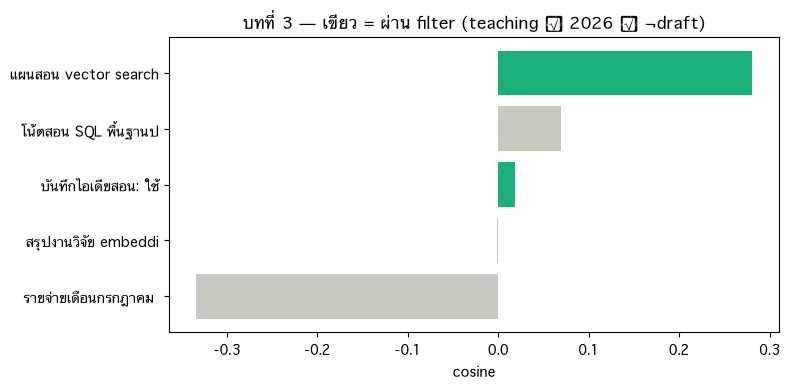

In [8]:
# @@VIZ@@
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
_thai_fonts=['Thonburi','Loma','Sarabun','Noto Sans Thai','TH Sarabun New']
_av={f.name for f in _fm.fontManager.ttflist}
if not any(_f in _av for _f in _thai_fonts):
    # Colab/Linux ไม่มีฟอนต์ไทยติดเครื่องมาเลย (DejaVu Sans เรนเดอร์ไทยไม่ได้) — ลงครั้งเดียวแล้ว cache ไว้
    import subprocess
    subprocess.run(['apt-get','-qq','install','-y','fonts-thai-tlwg'], capture_output=True)
    for _p in _fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/tlwg']):
        _fm.fontManager.addfont(_p)
    _av={f.name for f in _fm.fontManager.ttflist}
for _f in _thai_fonts:
    if _f in _av: matplotlib.rcParams['font.family']=_f; break
matplotlib.rcParams['axes.unicode_minus']=False
Q='การสอนเรื่องค้นหาด้วยความหมาย'
res=col.query(query_texts=[Q],n_results=6)
docs=res['documents'][0]; metas=res['metadatas'][0]; sc=[1-d for d in res['distances'][0]]
passed=[m['folder']=='teaching' and m['year']==2026 and not m['draft'] for m in metas]
c=['#1baf7a' if p else '#c9c7bf' for p in passed]; lb=[d[:20] for d in docs]
plt.figure(figsize=(8,4)); plt.barh(lb[::-1],sc[::-1],color=c[::-1])
plt.title('บทที่ 3 — เขียว = ผ่าน filter (teaching ∧ 2026 ∧ ¬draft)')
plt.xlabel('cosine'); plt.tight_layout(); plt.show()


## 🏋️ แบบฝึก
1. หา "ทุกอย่างที่ไม่ใช่เรื่องสอน" ด้วย `$ne`
2. filter เข้มจนผลว่าง (เช่น year 2030) — สังเกตว่าไม่ error แค่ list ว่าง — ทำไมเรื่องนี้สำคัญ?

**บทต่อไป:** `ch04_cosine_by_hand.ipynb` — เปิดฝาดูสมการข้างใน


In [9]:
#@title 🔑 เฉลย (คลิกลูกศรซ้ายเพื่อดูวิธีทำ) { display-mode: "form" }

# 1) หา "ทุกอย่างที่ไม่ใช่เรื่องสอน" ด้วย $ne
res_ne = col.query(query_texts=[Q], n_results=6, where={'folder': {'$ne': 'teaching'}})
print('=== ไม่ใช่เรื่องสอน (folder $ne teaching) ===')
for d, m in zip(res_ne['documents'][0], res_ne['metadatas'][0]):
    print('  ', d[:52], '·', m['folder'])

print()
# 2) filter เข้มจนผลว่าง (เช่น year 2030)
res_empty = col.query(query_texts=[Q], n_results=3, where={'year': {'$eq': 2030}})
print('=== filter year=2030 (ไม่มีโน้ตปีนี้เลย) ===')
print('documents:', res_empty['documents'])
print('→ ได้ list ว่างเปล่า [[]] ไม่ error — สำคัญเพราะโค้ดที่เรียกใช้ (เช่น RAG pipeline)')
print('  ต้องรองรับ "ไม่เจออะไรเลย" เป็นเคสปกติ ไม่ใช่ exception ที่ทำให้โปรแกรมล่ม')


=== ไม่ใช่เรื่องสอน (folder $ne teaching) ===
   สรุปงานวิจัย embedding หลายภาษา · research
   รายจ่ายเดือนกรกฎาคม ค่ากาแฟ 1,200 บาท · finance

=== filter year=2030 (ไม่มีโน้ตปีนี้เลย) ===
documents: [[]]
→ ได้ list ว่างเปล่า [[]] ไม่ error — สำคัญเพราะโค้ดที่เรียกใช้ (เช่น RAG pipeline)
  ต้องรองรับ "ไม่เจออะไรเลย" เป็นเคสปกติ ไม่ใช่ exception ที่ทำให้โปรแกรมล่ม
